# Ejercicios Prácticos - Redes neuronales profundas y redes neuronales convolucionales

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1.  Utiliza una red neuronal profunda para modelar el conjunto de datos “California housing”, puedes usar este código para cargar las muestras:




In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
df = pd.DataFrame(california.data,
columns=california.feature_names)
df['MedHouseVal'] = california.target # Columna objetivo

**a)** Divide en entrenamiento y test y normaliza las muestras.

**b)** Diseña una red profunda con 256 neuronas en la primera capa oculta, 128 en la segunda, 64 en la tercera y 32 en la cuarta.

**c)** Entrena la red durante 50 épocas de entrenamiento. Usa un tamaño de lote de entrenamiento de 8 y Adam como método de optimización, usa una tasa de aprendizaje 0.001.

**d)** Dibuja la evolución del ECM a lo largo del entrenamiento tanto en entrenamiento como en validación. A continuación, te muestro un ejemplo de cómo podría ser esta evolución:


<div align="center">

  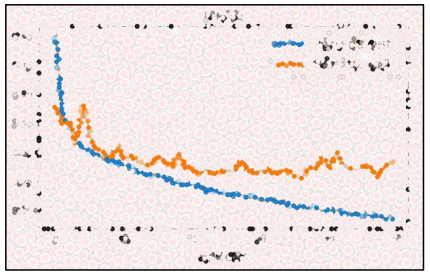

</div>

**e)** ¿Crees que la red está sobreajustada? ¿qué podrías aplicar si fuera así? Razona tus respuestas.

**f)** Calcula el coeficiente de determinación en el conjunto validación.

*Nota: Recuerda que para hacer este ejercicio puedes ayudarte de las funciones
auxiliares definidas en la práctica guiada.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target # Columna objetivo

In [3]:
# APARTADO A)

X = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Dividimos en entrenamiento y test y normalizamos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_ent_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_ent_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [4]:
# APARTADO B)

torch.manual_seed(10)

num_rasgos = X_ent_t.shape[1]

# Red profunda: 256 -> 128 -> 64 -> 32 -> 1 (Salida)
modelo = nn.Sequential(
    nn.Linear(num_rasgos, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)  # Una única salida continua
)

modelo

Sequential(
  (0): Linear(in_features=8, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=1, bias=True)
)

In [5]:
def entrenar(modelo_red, num_epocas, ent_dataloader, X_valid, y_valid,
             func_perdida, metodo_optimiza, clasificacion=False):
    """
    Entrena una red neuronal y devuelve históricos de pérdida y exactitud.

    Parámetros:
    -----------
    modelo_red        : torch.nn.Module  — Red a entrenar.
    num_epocas        : int              — Número de épocas.
    ent_dataloader    : DataLoader       — Lotes de entrenamiento.
    X_valid           : torch.Tensor     — Rasgos de validación.
    y_valid           : torch.Tensor     — Salidas deseadas de validación.
    func_perdida      : callable         — Función de pérdida.
    metodo_optimiza   : Optimizer        — Optimizador.
    clasificacion     : bool             — Si True, calcula exactitud también.

    Devuelve:
    ---------
    loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val
    """
    loss_hist_ent  = [0] * num_epocas
    exact_hist_ent = [0] * num_epocas
    loss_hist_val  = [0] * num_epocas
    exact_hist_val = [0] * num_epocas

    for epoca in range(num_epocas):
        # ---- Entrenamiento lote a lote ----
        for x_lote, y_lote in ent_dataloader:
            # FORWARD
            pred = modelo_red(x_lote)
            if pred.size(1) == 1:           # una sola neurona de salida
                pred = pred[:, 0]
            loss = func_perdida(pred, y_lote)

            # BACKWARD
            loss.backward()
            metodo_optimiza.step()
            metodo_optimiza.zero_grad()

            loss_hist_ent[epoca] += loss.item()

            if clasificacion:
                if pred.dim() == 1:
                    clase_pred = (pred >= 0.5).float()
                else:
                    clase_pred = torch.argmax(pred, dim=1)
                correcto = (clase_pred == y_lote).float()
                exact_hist_ent[epoca] += correcto.mean().item()

        # Promedio por lote
        loss_hist_ent[epoca] /= len(ent_dataloader)
        if clasificacion:
            exact_hist_ent[epoca] /= len(ent_dataloader)

        # ---- Validación ----
        with torch.no_grad():
            pred = modelo_red(X_valid)
            if pred.size(1) == 1:
                pred = pred[:, 0]
            loss = func_perdida(pred, y_valid)
            loss_hist_val[epoca] = loss.item()

            if clasificacion:
                if pred.dim() == 1:
                    clase_pred = (pred >= 0.5).float()
                else:
                    clase_pred = torch.argmax(pred, dim=1)
                correcto = (clase_pred == y_valid).float()
                exact_hist_val[epoca] = correcto.mean().item()

        if (epoca + 1) % 10 == 0:
            print(f"Época {epoca+1}/{num_epocas} | "
                  f"ECM Ent.: {loss_hist_ent[epoca]:.4f} | "
                  f"ECM Val.: {loss_hist_val[epoca]:.4f}")

    return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [6]:
# APARTADO C)

# Creamos el DataLoader (Tamaño de lote = 8)
tam_lote = 8
ent_dataset = TensorDataset(X_ent_t, y_ent_t)
ent_dl = DataLoader(ent_dataset, batch_size=tam_lote, shuffle=True)

# Función de pérdida y optimizador indicadas
func_perdida = nn.MSELoss()
optimizador  = optim.Adam(modelo.parameters(), lr=0.001)

historico = entrenar(modelo, 50, ent_dl, X_test_t, y_test_t, func_perdida, optimizador, clasificacion=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Época 10/50 | ECM Ent.: 0.2786 | ECM Val.: 0.4110
Época 20/50 | ECM Ent.: 0.2457 | ECM Val.: 0.2776
Época 30/50 | ECM Ent.: 0.2186 | ECM Val.: 0.2835
Época 40/50 | ECM Ent.: 0.2009 | ECM Val.: 0.2673
Época 50/50 | ECM Ent.: 0.1840 | ECM Val.: 0.2638


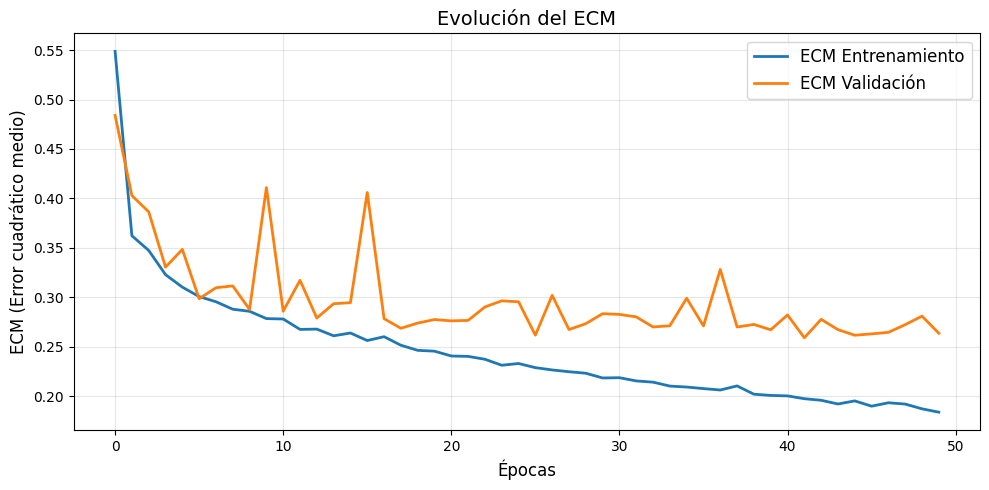

In [7]:
# APARTADO D)

plt.figure(figsize=(10, 5))

plt.plot(historico[0], label='ECM Entrenamiento', lw=2)
plt.plot(historico[1], label='ECM Validación', lw=2)
plt.title("Evolución del ECM", fontsize=14)
plt.xlabel("Épocas", fontsize=12)
plt.ylabel("ECM (Error cuadrático medio)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**APARTADO E)**

**Sí**, el ECM de validación es notablemente mayor que el de entrenamiento y, además, la curva de validación diverge o sube mientras la de entrenamiento sigue bajando, la red está sobreajustada.

Algunas medidas para combatir el sobreajuste en redes profundas serían:

  1. **Dropout**: durante el entrenamiento se
     desactivan neuronas de las capas ocultas con probabilidad p, evitando que la red dependa en exceso de
     neuronas concretas y forzando modelos más generales.

  2. **Regularización L2** (weight_decay en Adam).

  3. **Reducción** la **complejidad** del modelo (menos neuronas o  menos capas).

In [8]:
# APARTADO F)

modelo.eval()
with torch.no_grad():
    pred_val = modelo(X_test_t)
    pred_val = pred_val[:, 0].numpy()  # elimina dimensión extra

r2 = r2_score(y_test, pred_val)

print(f"Coeficiente de determinación (R^2) en validación: {r2:.4f}")

Coeficiente de determinación (R^2) en validación: 0.8067


2. Utiliza una red neuronal profunda para modelar el conjunto de datos
“Covertype” que consta de medio millón de muestras con 54 rasgos. Puedes usar este código para cargar las muestras:


In [9]:
from sklearn.datasets import fetch_covtype
data = fetch_covtype()
X, y = data.data, data.target - 1 # Ajustar etiquetas para que comiencen en 0

**a)** Divide en entrenamiento y test y normaliza las muestras.

**b)** Diseña y entrena una red profunda que logre una exactitud en validación superior al 92% en menos de 50 épocas de entrenamiento.

**c)** Dibuja la evolución tanto de la pérdida como de la exactitud, a lo largo del entrenamiento tanto en entrenamiento como en validación.

**d)** ¿Este conjunto de muestras se podría modelar con una red neuronal convolucional? Razona tu respuesta. Tienes una descripción detallada del conjunto de muestras en esta página web: https://archive.ics.uci.edu/dataset/31/covertype

También tienes una versión en español aquí:
https://archive-ics-uciedu.translate.goog/dataset/31/covertype?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es419&_x_tr_pto=wapp

*Nota: Recuerda que para hacer este ejercicio puedes ayudarte de las funciones auxiliares definidas en la práctica guiada.*

In [10]:
# APARTADO A)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_ent_t  = torch.tensor(X_train_scaled, dtype=torch.float32)
y_ent_t  = torch.tensor(y_train,        dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t = torch.tensor(y_test,         dtype=torch.long)

In [11]:
# APARTADO B)

num_rasgos = X_ent_t.shape[1]
num_clases = len(np.unique(y))

torch.manual_seed(10)

modelo = nn.Sequential(
    nn.Linear(54, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),

    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(128, num_clases)    # 7 clases de salida
)

modelo

Sequential(
  (0): Linear(in_features=54, out_features=512, bias=True)
  (1): ReLU()
  (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.2, inplace=False)
  (9): Linear(in_features=128, out_features=7, bias=True)
)

In [12]:
def entrenar(modelo_red, num_epocas, ent_dataloader, X_valid, y_valid,
             func_perdida, metodo_optimiza, clasificacion=False):
    loss_hist_ent  = [0] * num_epocas
    exact_hist_ent = [0] * num_epocas
    loss_hist_val  = [0] * num_epocas
    exact_hist_val = [0] * num_epocas

    for epoca in range(num_epocas):
        # ---- Entrenamiento lote a lote ----
        for x_lote, y_lote in ent_dataloader:
            pred = modelo_red(x_lote)
            if pred.size(1) == 1:
                pred = pred[:, 0]
            loss = func_perdida(pred, y_lote)

            loss.backward()
            metodo_optimiza.step()
            metodo_optimiza.zero_grad()

            loss_hist_ent[epoca] += loss.item()

            if clasificacion:
                if pred.dim() == 1:
                    clase_pred = (pred >= 0.5).float()
                else:
                    clase_pred = torch.argmax(pred, dim=1)
                correcto = (clase_pred == y_lote).float()
                exact_hist_ent[epoca] += correcto.mean().item()

        loss_hist_ent[epoca] /= len(ent_dataloader)
        if clasificacion:
            exact_hist_ent[epoca] /= len(ent_dataloader)

        # ---- Validación ----
        with torch.no_grad():
            pred = modelo_red(X_valid)
            if pred.size(1) == 1:
                pred = pred[:, 0]
            loss = func_perdida(pred, y_valid)
            loss_hist_val[epoca] = loss.item()

            if clasificacion:
                if pred.dim() == 1:
                    clase_pred = (pred >= 0.5).float()
                else:
                    clase_pred = torch.argmax(pred, dim=1)
                correcto = (clase_pred == y_valid).float()
                exact_hist_val[epoca] = correcto.mean().item()

        if (epoca + 1) % 5 == 0:
            print(f"Época {epoca+1:2d}/{num_epocas} | "
                  f"Pérd. Ent.: {loss_hist_ent[epoca]:.4f} | "
                  f"Pérd. Val.: {loss_hist_val[epoca]:.4f} | "
                  f"Exact. Ent.: {exact_hist_ent[epoca]:.4f} | "
                  f"Exact. Val.: {exact_hist_val[epoca]:.4f}")

    return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [13]:
# Creamos DataLoader para entrenamiento
tam_lote = 256
ent_dataset = TensorDataset(X_ent_t, y_ent_t)
ent_dl = DataLoader(ent_dataset, batch_size=tam_lote, shuffle=True)

func_perdida = nn.CrossEntropyLoss()
optimizador  = optim.Adam(modelo.parameters(), lr=0.001)

torch.manual_seed(10)

historico = entrenar(modelo, 20, ent_dl, X_test_t, y_test_t, func_perdida, optimizador, clasificacion=True)

Época  5/20 | Pérd. Ent.: 0.2548 | Pérd. Val.: 0.2411 | Exact. Ent.: 0.8947 | Exact. Val.: 0.9017
Época 10/20 | Pérd. Ent.: 0.2032 | Pérd. Val.: 0.1997 | Exact. Ent.: 0.9166 | Exact. Val.: 0.9177
Época 15/20 | Pérd. Ent.: 0.1801 | Pérd. Val.: 0.1799 | Exact. Ent.: 0.9257 | Exact. Val.: 0.9277
Época 20/20 | Pérd. Ent.: 0.1643 | Pérd. Val.: 0.1648 | Exact. Ent.: 0.9319 | Exact. Val.: 0.9332


In [14]:
exact_val_final = historico[3][-1]
print(f"Exactitud final en validación: {exact_val_final*100:.2f}%")

Exactitud final en validación: 93.32%


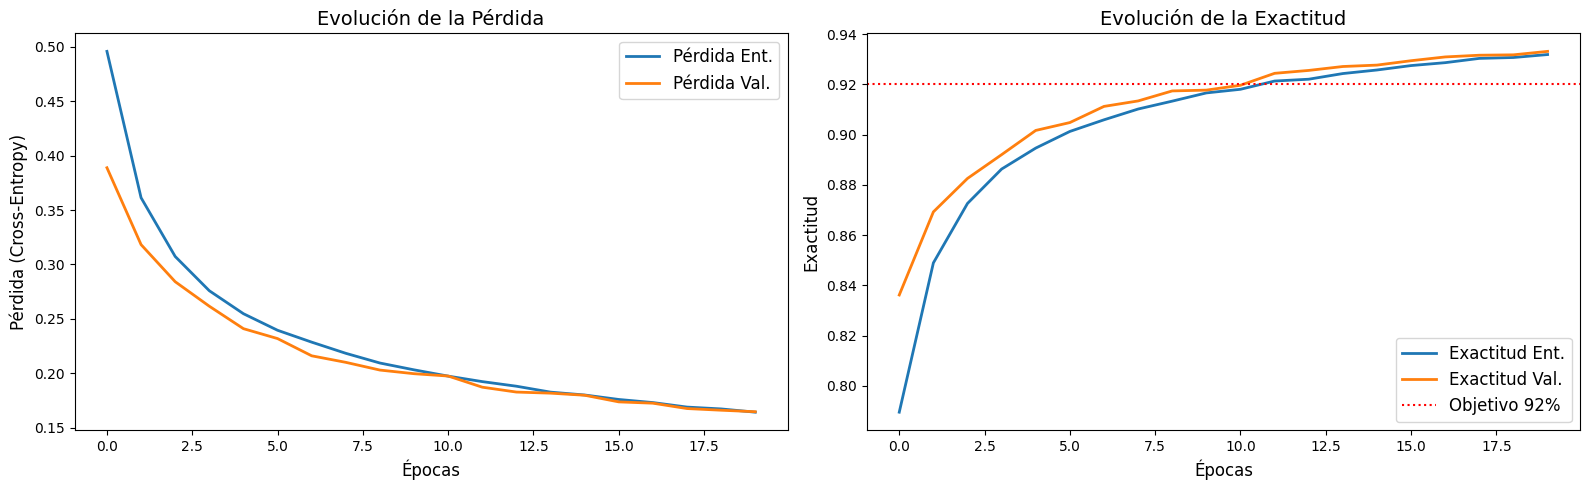

In [15]:
# APARTADO C)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(historico[0], lw=2, label='Pérdida Ent.')
axes[0].plot(historico[1], lw=2, label='Pérdida Val.')
axes[0].set_title('Evolución de la Pérdida', fontsize=14)
axes[0].set_xlabel('Épocas', fontsize=12)
axes[0].set_ylabel('Pérdida (Cross-Entropy)', fontsize=12)
axes[0].legend(fontsize=12)

axes[1].plot(historico[2], lw=2, label='Exactitud Ent.')
axes[1].plot(historico[3], lw=2, label='Exactitud Val.')
axes[1].axhline(y=0.92, color='red', lw=1.5, linestyle=':', label='Objetivo 92%')
axes[1].set_title('Evolución de la Exactitud', fontsize=14)
axes[1].set_xlabel('Épocas', fontsize=12)
axes[1].set_ylabel('Exactitud', fontsize=12)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

**APARTADO D)**

El conjunto Covertype tiene 54 rasgos por muestra:
  - 10 rasgos numéricos continuos
  - 44 rasgos binarios

Para usar una CNN es necesario que exista una **relación de vecindad** entre los rasgos de entrada, como ocurre con los píxeles de
una imagen (donde los píxeles cercanos comparten informacion local).

En Covertype no existe esta relación. Por tanto, no es adecuado usar una CNN para Covertype. Una red neuronal profunda totalmente conectada es la arquitectura correcta para este tipo de datos.

3. Utiliza una red neuronal convolucional para modelar el conjunto de datos “CIFAR10”. Tienes una descripción detallada del conjunto de muestras en esta página web:

    https://www.tensorflow.org/datasets/catalog/cifar10?hl=es

    **a)** Divide en entrenamiento y test.

    **b)** Configura una red neuronal convolucional con cuatro etapas de convolución+submuestreo y una última etapa con una capa oculta+desactivación.

    i. Utiliza aceleración GPU y entrena el modelo durante un máximo de 20 épocas usando como optimizador el método Adam.

    ii. Debes lograr una pérdida en entrenamiento igual o menor a 0.1

    iii. Muestra por pantalla la pérdida en entrenamiento en cada época.

    **OJO:** *NO utilices ninguna de las funciones auxiliares definidas en la práctica guiada, es decir, usa un script con funciones de la biblioteca Pytorch, tal y como se hace en el segundo proyecto de la práctica guiada.*

    **c)** Calcula la exactitud en test del modelo entrenado.


In [16]:
# APARTADO A)

transformacion = transforms.Compose([
    transforms.ToTensor()
])

ruta_archivos = './Imagenes'

# Descarga y división automática en Entrenamiento y Test
train_dataset = datasets.CIFAR10(root=ruta_archivos, train=True, download=True, transform=transformacion)
test_dataset = datasets.CIFAR10(root=ruta_archivos, train=False, download=True, transform=transformacion)

ent_dl = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 170M/170M [00:10<00:00, 16.6MB/s]


In [17]:
# APARTADO B)

modelo_cifar = nn.Sequential(

    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(256 * 2 * 2, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),  # Desactivación de neuronas para control de sobreajuste
    nn.Linear(512, 10)  # 10 clases deseadas de CIFAR-10
)

modelo_cifar

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU()
  (15): MaxPool2d(kernel_size=2, stri

In [18]:
# Configuración del optimizador Adam y la función de pérdida
func_perdida = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_cifar.parameters(), lr=0.001)

num_epocas = 20
torch.manual_seed(1)

for epoca in range(num_epocas):
    modelo_cifar.train()
    perdida_acumulada = 0.0

    for lote_imagenes, lote_etiquetas in ent_dl:

        # FORWARD
        salidas = modelo_cifar(lote_imagenes)
        perdida = func_perdida(salidas, lote_etiquetas)

        # BACKWARD y optimización
        optimizador.zero_grad()
        perdida.backward()
        optimizador.step()

        perdida_acumulada += perdida.item()

    # Calcular la pérdida media del entrenamiento de la época actual
    perdida_media_ent = perdida_acumulada / len(ent_dl)
    print(f"Época {epoca+1:02d}/{num_epocas} : Pérdida en entrenamiento: {perdida_media_ent:.4f}")

    # Detenemos el entrenamiento
    if perdida_media_ent <= 0.1:
        break

Época 01/20 : Pérdida en entrenamiento: 1.3047
Época 02/20 : Pérdida en entrenamiento: 0.8875
Época 03/20 : Pérdida en entrenamiento: 0.7093
Época 04/20 : Pérdida en entrenamiento: 0.5998
Época 05/20 : Pérdida en entrenamiento: 0.5093
Época 06/20 : Pérdida en entrenamiento: 0.4288
Época 07/20 : Pérdida en entrenamiento: 0.3614
Época 08/20 : Pérdida en entrenamiento: 0.3016
Época 09/20 : Pérdida en entrenamiento: 0.2425
Época 10/20 : Pérdida en entrenamiento: 0.1992
Época 11/20 : Pérdida en entrenamiento: 0.1596
Época 12/20 : Pérdida en entrenamiento: 0.1337
Época 13/20 : Pérdida en entrenamiento: 0.1191
Época 14/20 : Pérdida en entrenamiento: 0.0923


In [19]:
# APARTADO C)

modelo_cifar.eval()
correctas = 0
total = 0

with torch.no_grad():
    for lote_imagenes, lote_etiquetas in test_dl:

        # Predicción
        salidas = modelo_cifar(lote_imagenes)

        # Obtener los índices de la clase con la puntuación más alta
        _, clases_predichas = torch.max(salidas, dim=1)

        total += lote_etiquetas.size(0)
        correctas += (clases_predichas == lote_etiquetas).sum().item()

exactitud_test = (correctas / total) * 100
print(f"Exactitud final en el conjunto de test: {exactitud_test:.2f}%")

Exactitud final en el conjunto de test: 75.97%


## Ejercicio Avanzado

4. Utiliza una red neuronal convolucional para eliminar el ruido en imágenes, haciendo uso del conjunto de datos “CIFAR10”. Tienes una descripción detallada del conjunto de muestras en esta página web:

    https://www.tensorflow.org/datasets/catalog/cifar10?hl=es

    Las imágenes de entrada para la red han de ser imágenes de CIFAR10 corrompidas con ruido de la siguiente forma:

    ```
    ruido = torch.randn_like(imagen) * 0.1
    imagen_ruidosa = torch.clip(imagen + ruido, 0., 1.)
    ```

    Las imágenes de salida ideales han de ser las imágenes originales sin ruido.

    **a)** Divide en entrenamiento y test. Configura una red neuronal convolucional con la siguiente arquitectura:

In [5]:
class DenoisingCNN(nn.Module):
  def __init__(self):
    super(DenoisingCNN, self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2)
    )
    self.decoder = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(64, 3, kernel_size=3, padding=1),
        nn.Sigmoid()
    )

  def forward(self, x):
      x = self.encoder(x)
      x = self.decoder(x)
      return x

Explica la arquitectura indicada.

**b)** Utiliza aceleración GPU, el error cuadrático medio (Mean Squared Error, MSE) como función de pérdida, y entrena el modelo durante un máximo de 20 épocas usando como optimizador el método Adam, con una tasa de aprendizaje de 0.001. Debes lograr una pérdida en entrenamiento igual o menor a 0.002.

**c)** Muestra por pantalla la pérdida en entrenamiento y en test, en cada época.

**d)** Muestra al menos cinco ejemplos de imágenes de test, visualizando la imagen ruidosa de entrada, la imagen de salida de la red, y la imagen original sin ruido.

**OJO:** *NO utilices ninguna de las funciones auxiliares definidas en la práctica guiada, es decir, usa un script con funciones de la biblioteca Pytorch, tal y como se hace en el segundo proyecto de la práctica guiada.*

In [2]:
import torch

# Determinar el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo actual: {device}")

Dispositivo actual: cuda


In [3]:
# APARTADO A)

transformacion = transforms.Compose([
    transforms.ToTensor()
])

ruta_archivos = './Imagenes'
train_dataset = datasets.CIFAR10(root=ruta_archivos, train=True, download=True, transform=transformacion)
test_dataset = datasets.CIFAR10(root=ruta_archivos, train=False, download=True, transform=transformacion)

ent_dl = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 170M/170M [00:08<00:00, 20.7MB/s]


In [6]:
modelo_denoise = DenoisingCNN().to(device)

modelo_denoise

DenoisingCNN(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=2.0, mode='nearest')
    (3): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Sigmoid()
  )
)

La arquitectura del modelo se divide simétricamente en dos bloques principales: un codificador (encoder) que comprime la imagen extrayendo sus rasgos esenciales y eliminando el ruido aleatorio, y un decodificador (decoder) que reconstruye la imagen limpia a su tamaño original.

In [7]:
# APARTADOS B) Y C)

# Configuración de optimizador y pérdida MSE
func_perdida = nn.MSELoss()
optimizador = optim.Adam(modelo_denoise.parameters(), lr=0.001)

num_epocas = 20
torch.manual_seed(10)

for epoca in range(num_epocas):

    modelo_denoise.train()
    perdida_acum_ent = 0.0

    for imagenes_originales, _ in ent_dl:

        imagenes_originales = imagenes_originales.to(device)

        # Generamos y aplicamos el ruido (hereda el dispositivo de imagenes_originales)
        ruido = torch.randn_like(imagenes_originales) * 0.1
        imagenes_ruidosas = torch.clip(imagenes_originales + ruido, 0., 1.)

        imagenes_reconstruidas = modelo_denoise(imagenes_ruidosas)

        loss = func_perdida(imagenes_reconstruidas, imagenes_originales)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        perdida_acum_ent += loss.item()

    perdida_media_ent = perdida_acum_ent / len(ent_dl)

    modelo_denoise.eval()
    perdida_acum_test = 0.0

    with torch.no_grad():
        for imagenes_originales_test, _ in test_dl:

            imagenes_originales_test = imagenes_originales_test.to(device)

            # Aplicar ruido en el conjunto de test
            ruido_test = torch.randn_like(imagenes_originales_test) * 0.1
            imagenes_ruidosas_test = torch.clip(imagenes_originales_test + ruido_test, 0., 1.)

            # Pasar la imagen ruidosa de test
            imagenes_reconstruidas_test = modelo_denoise(imagenes_ruidosas_test)
            loss_test = func_perdida(imagenes_reconstruidas_test, imagenes_originales_test)

            perdida_acum_test += loss_test.item()

    perdida_media_test = perdida_acum_test / len(test_dl)

    print(f"Época {epoca+1:02d}/{num_epocas} : Pérdida Entrenamiento: {perdida_media_ent:.5f} | Pérdida Test: {perdida_media_test:.5f}")

    # Condición de parada
    if perdida_media_ent <= 0.002:
        break

Época 01/20 : Pérdida Entrenamiento: 0.00859 | Pérdida Test: 0.00365
Época 02/20 : Pérdida Entrenamiento: 0.00316 | Pérdida Test: 0.00279
Época 03/20 : Pérdida Entrenamiento: 0.00269 | Pérdida Test: 0.00252
Época 04/20 : Pérdida Entrenamiento: 0.00252 | Pérdida Test: 0.00241
Época 05/20 : Pérdida Entrenamiento: 0.00239 | Pérdida Test: 0.00229
Época 06/20 : Pérdida Entrenamiento: 0.00232 | Pérdida Test: 0.00224
Época 07/20 : Pérdida Entrenamiento: 0.00230 | Pérdida Test: 0.00217
Época 08/20 : Pérdida Entrenamiento: 0.00219 | Pérdida Test: 0.00216
Época 09/20 : Pérdida Entrenamiento: 0.00217 | Pérdida Test: 0.00226
Época 10/20 : Pérdida Entrenamiento: 0.00211 | Pérdida Test: 0.00246
Época 11/20 : Pérdida Entrenamiento: 0.00210 | Pérdida Test: 0.00204
Época 12/20 : Pérdida Entrenamiento: 0.00210 | Pérdida Test: 0.00204
Época 13/20 : Pérdida Entrenamiento: 0.00203 | Pérdida Test: 0.00235
Época 14/20 : Pérdida Entrenamiento: 0.00203 | Pérdida Test: 0.00203
Época 15/20 : Pérdida Entrenamient

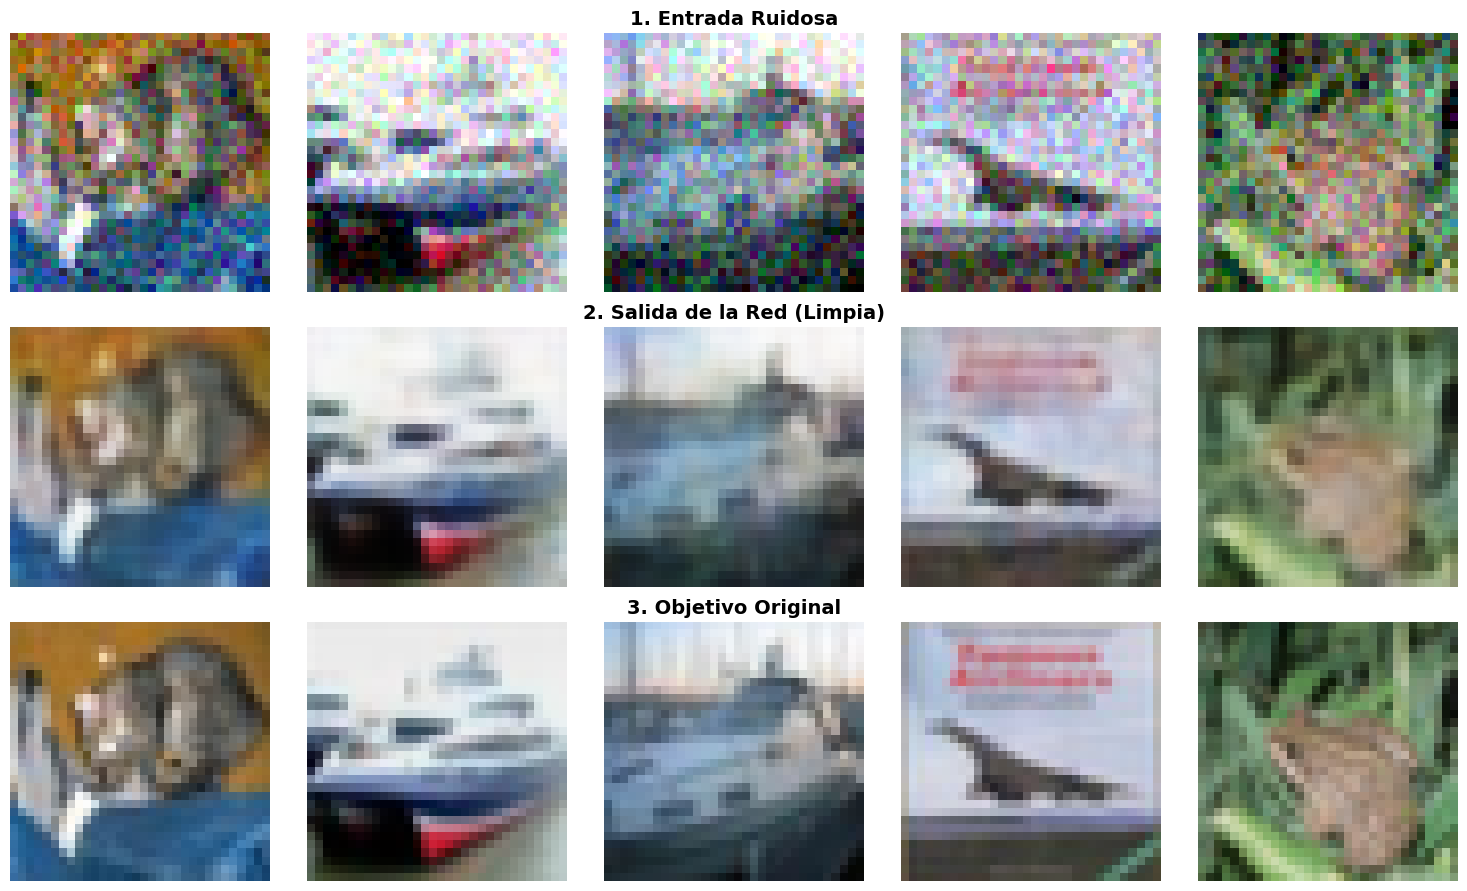

In [8]:
# APARTADO D)

modelo_denoise.eval()
data_iter = iter(test_dl)
imagenes_originales_ejemplo, _ = next(data_iter)

imagenes_originales_ejemplo = imagenes_originales_ejemplo.to(device)

ruido_ejemplo = torch.randn_like(imagenes_originales_ejemplo) * 0.1
imagenes_ruidosas_ejemplo = torch.clip(imagenes_originales_ejemplo + ruido_ejemplo, 0., 1.)

with torch.no_grad():
    imagenes_reconstruidas_ejemplo = modelo_denoise(imagenes_ruidosas_ejemplo)

# Formatear dimensiones para Matplotlib (C, H, W) -> (H, W, C)
imagenes_originales_ejemplo = imagenes_originales_ejemplo.cpu().permute(0, 2, 3, 1).numpy()
imagenes_ruidosas_ejemplo = imagenes_ruidosas_ejemplo.cpu().permute(0, 2, 3, 1).numpy()
imagenes_reconstruidas_ejemplo = imagenes_reconstruidas_ejemplo.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Ruidosa
    axes[0, i].imshow(imagenes_ruidosas_ejemplo[i])
    axes[0, i].axis('off')
    if i == 2: axes[0, i].set_title("1. Entrada Ruidosa", fontsize=14, weight='bold')

    # Reconstruida por la CNN
    axes[1, i].imshow(imagenes_reconstruidas_ejemplo[i])
    axes[1, i].axis('off')
    if i == 2: axes[1, i].set_title("2. Salida de la Red (Limpia)", fontsize=14, weight='bold')

    # Original
    axes[2, i].imshow(imagenes_originales_ejemplo[i])
    axes[2, i].axis('off')
    if i == 2: axes[2, i].set_title("3. Objetivo Original", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## Ejercicio Experto

5. Utiliza una red neuronal convolucional para aumentar la resolución de imágenes, haciendo uso del conjunto de datos “CIFAR10”. Tienes una descripción detallada del conjunto de muestras en esta página web:

    https://www.tensorflow.org/datasets/catalog/cifar10?hl=es

    Las imágenes de entrada para la red han de ser imágenes de CIFAR10 reducidas a una resolución de 16x16 píxeles y posteriormente reconstruidas a 32x32 píxeles de la siguiente forma:

    ```
    imagen_reducida = transforms.Resize((16, 16))(imagen_original)
    imagen_reconstruida = transforms.Resize((32, 32))(imagen_reducida)
    ```

    Las imágenes de salida ideales han de ser las imágenes originales de resolución 32x32 píxeles.

    **a)** Divide en entrenamiento y test. Configura una red neuronal convolucional con la siguiente arquitectura:

In [9]:
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(32, 3, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x

Explica la arquitectura indicada.

**b)** Utiliza aceleración GPU, el error cuadrático medio (Mean Squared Error, MSE) como función de pérdida, y entrena el modelo durante un máximo de 20 épocas usando como optimizador el método Adam, con una tasa de aprendizaje de 0.001. Debes lograr una pérdida en entrenamiento igual o menor a 0.0025.

**c)** Muestra por pantalla la pérdida en entrenamiento y en test, en cada época.

**d)** Muestra al menos cinco ejemplos de imágenes de test, visualizando la imagen reconstruida de entrada, la imagen de salida de la red, y la imagen original.

**OJO:** *NO utilices ninguna de las funciones auxiliares definidas en la práctica guiada, es decir, usa un script con funciones de la biblioteca Pytorch, tal y como se hace en el segundo proyecto de la práctica guiada.*


In [10]:
# APARTADO A)

transformacion = transforms.Compose([
    transforms.ToTensor()
])

ruta_archivos = './Imagenes'
train_dataset = datasets.CIFAR10(root=ruta_archivos, train=True, download=True, transform=transformacion)
test_dataset = datasets.CIFAR10(root=ruta_archivos, train=False, download=True, transform=transformacion)

ent_dl = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [11]:
modelo_srcnn = SRCNN().to(device)

SRCNN

__main__.SRCNN

La red consta de tres capas convolucionales que simulan un flujo de procesamiento de imágenes:

- Capa 1 (conv1 + relu1): Extrae parches de la imagen de entrada (degradada y reescalada) y los representa como mapas de características de alta dimensionalidad.

- Capa 2 (conv2 + relu2): Realiza un mapeo no lineal.

- Capa 3 (conv3): Reconstruye la imagen final.

In [13]:
# APARTADOS B) Y C)

# Configuración del optimizador Adam y pérdida MSE exigida
func_perdida = nn.MSELoss()
optimizador = optim.Adam(modelo_srcnn.parameters(), lr=0.001)

# Objetos de transformación para degradar la imagen según el enunciado
transform_reducir = transforms.Resize((16, 16))
transform_reconstruir = transforms.Resize((32, 32))

num_epocas = 20
torch.manual_seed(1)

for epoca in range(num_epocas):

    modelo_srcnn.train()
    perdida_acum_ent = 0.0

    for imagenes_originales, _ in ent_dl:

        # Generar las transformaciones
        img_reducida = transform_reducir(imagenes_originales)
        img_reconstruida_input = transform_reconstruir(img_reducida)

        img_reconstruida_input = img_reconstruida_input.to(device)
        imagenes_originales = imagenes_originales.to(device)

        salidas_alta_res = modelo_srcnn(img_reconstruida_input)
        loss = func_perdida(salidas_alta_res, imagenes_originales)

        # Backward y optimización
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        perdida_acum_ent += loss.item()

    perdida_media_ent = perdida_acum_ent / len(ent_dl)

    modelo_srcnn.eval()
    perdida_acum_test = 0.0

    with torch.no_grad():
        for imagenes_originales_test, _ in test_dl:

            img_reducida_test = transform_reducir(imagenes_originales_test)
            img_reconstruida_input_test = transform_reconstruir(img_reducida_test)

            img_reconstruida_input_test = img_reconstruida_input_test.to(device)
            imagenes_originales_test = imagenes_originales_test.to(device)

            salidas_alta_res_test = modelo_srcnn(img_reconstruida_input_test)
            loss_test = func_perdida(salidas_alta_res_test, imagenes_originales_test)

            perdida_acum_test += loss_test.item()

    perdida_media_test = perdida_acum_test / len(test_dl)

    # Mostrar el progreso de las pérdidas por época en entrenamiento y test
    print(f"Época {epoca+1:02d}/{num_epocas} : Pérdida Entrenamiento: {perdida_media_ent:.5f} | Pérdida Test: {perdida_media_test:.5f}")

    # Condición de parada
    if perdida_media_ent <= 0.0025:
        break

Época 01/20 : Pérdida Entrenamiento: 0.01313 | Pérdida Test: 0.00512
Época 02/20 : Pérdida Entrenamiento: 0.00401 | Pérdida Test: 0.00342
Época 03/20 : Pérdida Entrenamiento: 0.00337 | Pérdida Test: 0.00296
Época 04/20 : Pérdida Entrenamiento: 0.00289 | Pérdida Test: 0.00290
Época 05/20 : Pérdida Entrenamiento: 0.00275 | Pérdida Test: 0.00334
Época 06/20 : Pérdida Entrenamiento: 0.00272 | Pérdida Test: 0.00252
Época 07/20 : Pérdida Entrenamiento: 0.00256 | Pérdida Test: 0.00253
Época 08/20 : Pérdida Entrenamiento: 0.00253 | Pérdida Test: 0.00261
Época 09/20 : Pérdida Entrenamiento: 0.00248 | Pérdida Test: 0.00246


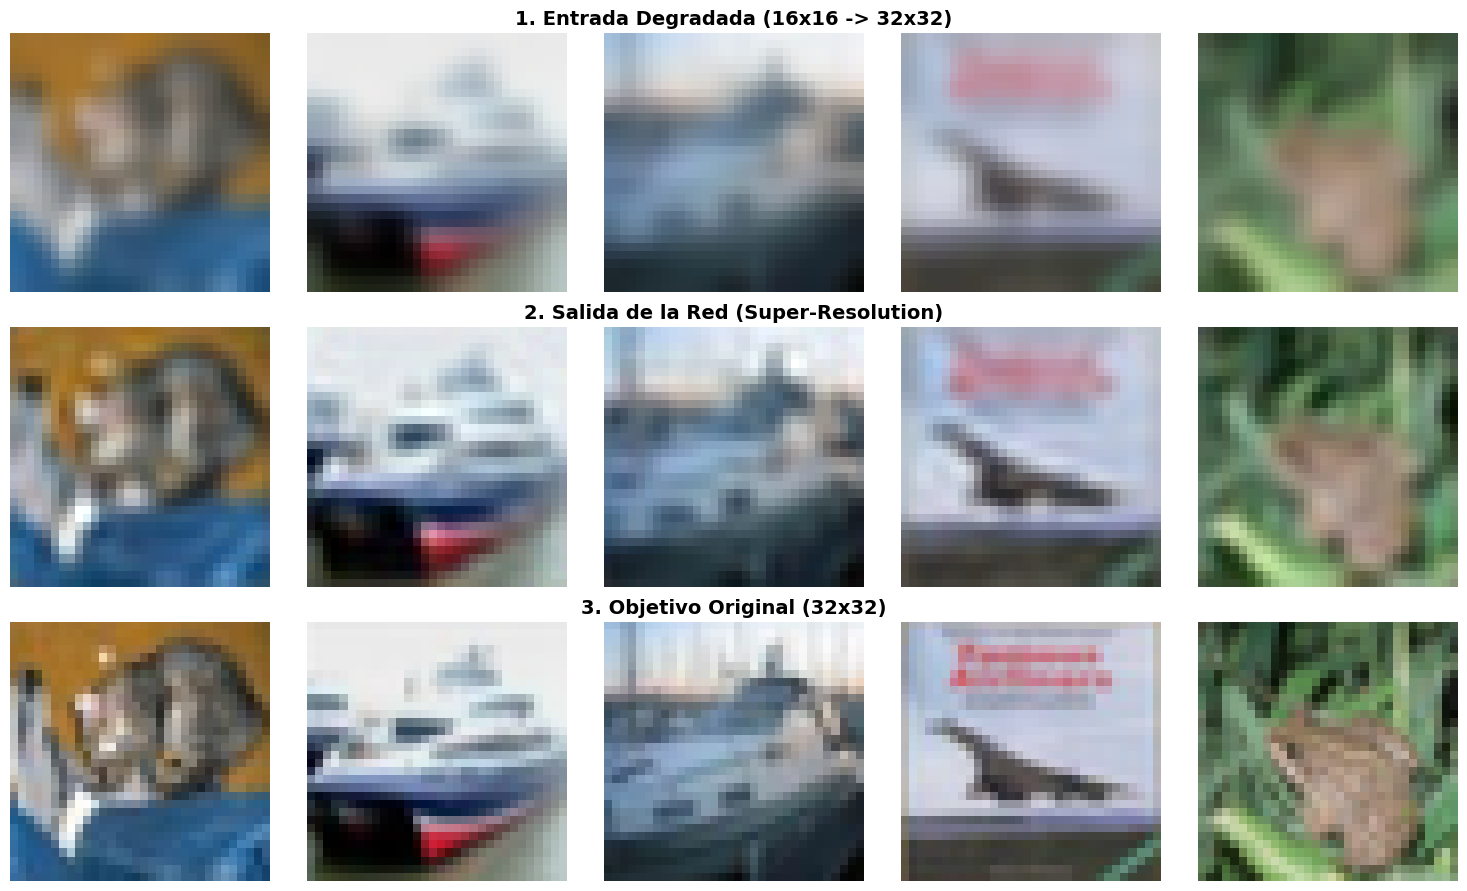

In [14]:
# APARTADO D)

modelo_srcnn.eval()
data_iter = iter(test_dl)
imagenes_originales_ejemplo, _ = next(data_iter)

# Generar degradación para la muestra visual
img_reducida_ej = transform_reducir(imagenes_originales_ejemplo)
img_reconstruida_input_ej = transform_reconstruir(img_reducida_ej)

img_reconstruida_input_ej = img_reconstruida_input_ej.to(device)

with torch.no_grad():
    salidas_srcnn_ej = modelo_srcnn(img_reconstruida_input_ej)
    # Ajustamos clip a la salida de la red para garantizar visualización correcta [0, 1] en matplotlib
    salidas_srcnn_ej = torch.clip(salidas_srcnn_ej, 0., 1.)

# Formatear dimensiones para Matplotlib (C, H, W) -> (H, W, C)
img_reconstruida_input_ej = img_reconstruida_input_ej.cpu().permute(0, 2, 3, 1).numpy()
salidas_srcnn_ej = salidas_srcnn_ej.cpu().permute(0, 2, 3, 1).numpy()
imagenes_originales_ejemplo = imagenes_originales_ejemplo.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Fila 1: Imagen reconstruida de entrada (Baja resolución pixelada)
    axes[0, i].imshow(img_reconstruida_input_ej[i])
    axes[0, i].axis('off')
    if i == 2: axes[0, i].set_title("1. Entrada Degradada (16x16 -> 32x32)", fontsize=14, weight='bold')

    # Fila 2: Imagen de salida de la red SRCNN (Detalles recuperados)
    axes[1, i].imshow(salidas_srcnn_ej[i])
    axes[1, i].axis('off')
    if i == 2: axes[1, i].set_title("2. Salida de la Red (Super-Resolution)", fontsize=14, weight='bold')

    # Fila 3: Imagen Original Ideal
    axes[2, i].imshow(imagenes_originales_ejemplo[i])
    axes[2, i].axis('off')
    if i == 2: axes[2, i].set_title("3. Objetivo Original (32x32)", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()